# Notebook para la preparación del modelo

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, StandardScaler, FunctionTransformer, KBinsDiscretizer,
)
from sklearn.metrics import (
    accuracy_score,    
    roc_auc_score,     
    log_loss,          
    precision_score,   
    recall_score,      
    f1_score,          
    matthews_corrcoef, 
    brier_score_loss   
)
import xgboost as xgb
import numpy as np
from sklearn.metrics import roc_auc_score
from sklearn.base import BaseEstimator, TransformerMixin
import tqdm
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-darkgrid')

In [2]:

transacciones_path = "./transacciones.parquet"
clientes_path = "./clientes.parquet"
productor_path = "./productos.parquet"
# 1) Cargar los datasets
df_trans = pd.read_parquet(transacciones_path)
df_clientes  = pd.read_parquet(clientes_path)
df_prod  = pd.read_parquet(productor_path)

## Merged dataset

In [3]:
# 2) Mostrar duplicados antes de limpiar
print("Duplicados en transacciones antes:", df_trans.duplicated().sum())
print("Duplicados en clientes     antes:", df_clientes.duplicated().sum())
print("Duplicados en productos    antes:", df_prod.duplicated().sum())

# 3) Eliminar duplicados exactos
# * Añadi un copy() para trabajar con una copia segura del dataframe. -David
df_trans_clean = df_trans.copy().drop_duplicates()
df_clientes_clean = df_clientes.copy().drop_duplicates()
df_prod_clean = df_prod.copy().drop_duplicates()

# 4) Mostrar duplicados después de limpiar
print("Duplicados en transacciones después:", df_trans_clean.duplicated().sum())
print("Duplicados en clientes     después:", df_clientes_clean.duplicated().sum())
print("Duplicados en productos    después:", df_prod_clean.duplicated().sum())

# 5) Normalizar tipos de ID a string para evitar conflictos en el merge
df_trans_clean["customer_id"] = df_trans_clean["customer_id"].astype(str)
df_trans_clean["product_id"] = df_trans_clean["product_id"].astype(str)
df_clientes_clean["customer_id"] = df_clientes_clean["customer_id"].astype(str)
df_prod_clean["product_id"] = df_prod_clean["product_id"].astype(str)

# 6) Convertir la fecha de compra a datetime
df_trans_clean["purchase_date"] = pd.to_datetime(df_trans_clean["purchase_date"])

# 7) Merge: primero transacciones + clientes, luego resultado + productos
df_merged = (
    df_trans_clean
    .merge(df_clientes_clean, on="customer_id", how="left")
    .merge(df_prod_clean, on="product_id", how="left")
)

# 8) Comprobar el resultado
print("\nShape del DataFrame combinado:", df_merged.shape)
print("\nPrimeras filas de df_merged:")
df_merged.head()

Duplicados en transacciones antes: 885
Duplicados en clientes     antes: 0
Duplicados en productos    antes: 0
Duplicados en transacciones después: 0
Duplicados en clientes     después: 0
Duplicados en productos    después: 0

Shape del DataFrame combinado: (254051, 18)

Primeras filas de df_merged:


,customer_id,product_id,order_id,purchase_date,items,region_id,zone_id,customer_type,Y,X,num_deliver_per_week,num_visit_per_week,brand,category,sub_category,segment,package,size
0,61353,61364,411145,2024-04-27,-0.333333,80,5148,ABARROTES,-46.558718,-107.860564,3,1,Brand 35,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,BOTELLA,1.00
1,61899,1370,411156,2024-04-27,3.666667,80,5148,MAYORISTA,-46.557632,-107.896470,3,1,Brand 34,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,BOTELLA,1.00
2,154077,30500,417911,2024-04-29,2.333333,80,5148,ABARROTES,-46.543598,-107.874170,3,1,Brand 31,BEBIDAS CARBONATADAS,GASEOSAS,PREMIUM,LATA,0.31
3,164337,56714,418100,2024-04-29,-2.333333,80,5148,ABARROTES,-46.549960,-107.863088,3,1,Brand 31,BEBIDAS CARBONATADAS,GASEOSAS,PREMIUM,BOTELLA,0.66
4,172056,61672,407162,2024-04-26,1.000000,80,5148,MAYORISTA,-46.564528,-107.927651,4,1,Brand 34,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,LATA,0.25


## EDA y outliers

## Generación labels

In [4]:
df_merged['year_week'] = df_merged['purchase_date'].dt.to_period('W').astype(str)

df_semanal = (
    df_merged
    .groupby(['customer_id', 'product_id', 'year_week'], as_index=False)
    .agg(items_sum=('items', 'sum'))
)

pares_unicos = df_merged[['customer_id', 'product_id']].drop_duplicates()

fechas_completas = pd.date_range(df_merged['purchase_date'].min(), df_merged['purchase_date'].max(), freq='D')
semanas_completas = pd.Series(fechas_completas.to_period('W').unique().astype(str), name='year_week')
semanas_completas_map = {week : f'week_{i+1}' for i, week in enumerate(semanas_completas)}

combinaciones_validas = pd.MultiIndex.from_frame(
    pares_unicos.assign(key=1).merge(semanas_completas.to_frame().assign(key=1), on='key').drop('key', axis=1)
)

df_semanal_idx = df_semanal.set_index(['customer_id', 'product_id', 'year_week'])
df_semanal_completo = df_semanal_idx.reindex(combinaciones_validas, fill_value=0).reset_index()
df_semanal_completo['label'] = (df_semanal_completo['items_sum'] > 0).astype(int)
df_semanal_completo['year_week'] = df_semanal_completo['year_week'].map(semanas_completas_map)

In [5]:
# 1) Extraer atributos constantes de cliente y producto
df_client = (
    df_merged[['customer_id','region_id','zone_id','customer_type',
               'Y','X','num_deliver_per_week','num_visit_per_week']]
    .drop_duplicates(subset='customer_id')
)
df_prod = (
    df_merged[['product_id','brand','category','sub_category','segment','package','size']]
    .drop_duplicates(subset='product_id')
)

# 2) Unir df_semanal_completo con atributos de cliente y producto
df_model = (
    df_semanal_completo
    .merge(df_client, on='customer_id', how='left')
    .merge(df_prod,   on='product_id',  how='left')
)

# 3) Eliminar cualquier columna de fecha (purchase_date_real) si existiera
df_model = df_model.drop(columns=[c for c in df_model.columns if 'purchase_date' in c], errors='ignore')

# 4) Verificar
print("Shape de df_model:", df_model.shape)
print("Columnas de df_model:", df_model.columns.tolist())
df_model.head()

Shape de df_model: (1617242, 18)
Columnas de df_model: ['customer_id', 'product_id', 'year_week', 'items_sum', 'label', 'region_id', 'zone_id', 'customer_type', 'Y', 'X', 'num_deliver_per_week', 'num_visit_per_week', 'brand', 'category', 'sub_category', 'segment', 'package', 'size']


,customer_id,product_id,year_week,items_sum,label,region_id,zone_id,customer_type,Y,X,num_deliver_per_week,num_visit_per_week,brand,category,sub_category,segment,package,size
0,61353,61364,week_1,0.0,0,80,5148,ABARROTES,-46.558718,-107.860564,3,1,Brand 35,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,BOTELLA,1.0
1,61353,61364,week_2,0.0,0,80,5148,ABARROTES,-46.558718,-107.860564,3,1,Brand 35,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,BOTELLA,1.0
2,61353,61364,week_3,0.0,0,80,5148,ABARROTES,-46.558718,-107.860564,3,1,Brand 35,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,BOTELLA,1.0
3,61353,61364,week_4,0.0,0,80,5148,ABARROTES,-46.558718,-107.860564,3,1,Brand 35,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,BOTELLA,1.0
4,61353,61364,week_5,0.0,0,80,5148,ABARROTES,-46.558718,-107.860564,3,1,Brand 35,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,BOTELLA,1.0


In [6]:
df_model['year_week'].unique()

array(['week_1', 'week_2', 'week_3', 'week_4', 'week_5', 'week_6',
       'week_7', 'week_8', 'week_9', 'week_10', 'week_11', 'week_12',
       'week_13', 'week_14', 'week_15', 'week_16', 'week_17', 'week_18',
       'week_19', 'week_20', 'week_21', 'week_22', 'week_23', 'week_24',
       'week_25', 'week_26', 'week_27', 'week_28', 'week_29', 'week_30',
       'week_31', 'week_32', 'week_33', 'week_34', 'week_35', 'week_36',
       'week_37', 'week_38', 'week_39', 'week_40', 'week_41', 'week_42',
       'week_43', 'week_44', 'week_45', 'week_46', 'week_47', 'week_48',
       'week_49', 'week_50', 'week_51', 'week_52', 'week_53'],
      dtype=object)

In [7]:
def filter_fun(group):
    purchase = group[group['label'] == 1]
    if purchase.empty:
        return pd.DataFrame()

    # obtener la fecha minima con una compra

    primera_fecha = purchase['year_week'].min()
    return group [ (group['label'] == 1) | (group['year_week'] >= primera_fecha) ]

df_model['year_week'] = df_model['year_week'].astype(str).str.replace('week_', '').astype(int)
df_modelo_filtrado = df_model.groupby(['customer_id', 'product_id'], group_keys=False).apply(filter_fun)

C:\Users\unaro\AppData\Local\Temp\ipykernel_18776\3235484037.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_modelo_filtrado = df_model.groupby(['customer_id', 'product_id'], group_keys=False).apply(filter_fun)


In [8]:
df_modelo_filtrado

,customer_id,product_id,year_week,items_sum,label,region_id,zone_id,customer_type,Y,X,num_deliver_per_week,num_visit_per_week,brand,category,sub_category,segment,package,size
1259129,123150,10652,9,1.666667,1,80,5148,ABARROTES,-46.694530,-107.832138,4,1,Brand 34,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,LATA,0.25
1259130,123150,10652,10,0.000000,0,80,5148,ABARROTES,-46.694530,-107.832138,4,1,Brand 34,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,LATA,0.25
1259131,123150,10652,11,0.000000,0,80,5148,ABARROTES,-46.694530,-107.832138,4,1,Brand 34,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,LATA,0.25
1259132,123150,10652,12,0.000000,0,80,5148,ABARROTES,-46.694530,-107.832138,4,1,Brand 34,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,LATA,0.25
1259133,123150,10652,13,0.000000,0,80,5148,ABARROTES,-46.694530,-107.832138,4,1,Brand 34,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,LATA,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1389022,96444,63418,52,0.000000,0,80,5148,ABARROTES,-46.524252,-108.230922,3,1,Brand 35,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,LATA,0.25
1389023,96444,63418,53,0.000000,0,80,5148,ABARROTES,-46.524252,-108.230922,3,1,Brand 35,BEBIDAS CARBONATADAS,GASEOSAS,MEDIUM,LATA,0.25
1342593,96444,63510,51,6.000000,1,80,5148,ABARROTES,-46.524252,-108.230922,3,1,Brand 44,BEBIDAS CARBONATADAS,GASEOSAS,HIGH,LATA,0.25
1342594,96444,63510,52,3.666667,1,80,5148,ABARROTES,-46.524252,-108.230922,3,1,Brand 44,BEBIDAS CARBONATADAS,GASEOSAS,HIGH,LATA,0.25


## Holdout

In [94]:
# crear los batches
df_modelo_filtrado['week_num'] = df_modelo_filtrado['year_week'].astype(int)
weeks = df_modelo_filtrado['week_num'].sort_values().unique()[:-1]
sliding_window_size = 4
stride = 3

weeks_batches = [
    weeks[i : i + sliding_window_size].tolist()
    for i in range(0, len(weeks) - sliding_window_size + 1, stride)
]

last_weeks = weeks[len(weeks) - sliding_window_size+2:-1].tolist()


if len(last_weeks) <= sliding_window_size//2:
    weeks_batches[-1] += last_weeks
else:
    weeks_batches += [last_weeks]
 

train_batch = lambda i : df_modelo_filtrado[df_modelo_filtrado['week_num'].isin((weeks_batches[i])[:-(sliding_window_size-stride)])]
val_batch = lambda i : df_modelo_filtrado[df_modelo_filtrado['week_num'].isin((weeks_batches[i])[(sliding_window_size-stride):])]
test_batch = df_modelo_filtrado[df_modelo_filtrado['week_num'] == weeks[-1]]

In [95]:
weeks_batches

[[1, 2, 3, 4],
 [4, 5, 6, 7],
 [7, 8, 9, 10],
 [10, 11, 12, 13],
 [13, 14, 15, 16],
 [16, 17, 18, 19],
 [19, 20, 21, 22],
 [22, 23, 24, 25],
 [25, 26, 27, 28],
 [28, 29, 30, 31],
 [31, 32, 33, 34],
 [34, 35, 36, 37],
 [37, 38, 39, 40],
 [40, 41, 42, 43],
 [43, 44, 45, 46],
 [46, 47, 48, 49],
 [49, 50, 51, 52, 51]]

In [11]:
val_batch(0)['week_num'].unique(), test_batch['week_num'].unique()

(array([3, 4]), array([52]))

In [12]:
train_batch(0)['week_num'].unique()

array([2, 1])

## Pipeline

In [16]:


class WeekExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self  # nada que ajustar

    def transform(self, X):
        week_nums = X['year_week'].str.extract(r'week_(\d+)')[0].astype(int)
        return pd.DataFrame({'week_num': week_nums}, index=X.index)

    def get_feature_names_out(self, input_features=None):
        return np.array(['week_num'])

class MedianImputer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.medians_ = X.median()
        return self

    def transform(self, X):
        return X.fillna(self.medians_)

    def get_feature_names_out(self, input_features=None):
        return input_features if input_features is not None else X.columns.to_list()
  

class ColumnReshaper(BaseEstimator, TransformerMixin):
    def __init__(self, column):
        self.column = column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X[[self.column]].values

    def get_feature_names_out(self, input_features=None):
        return [self.column]
    

class CategoricalImputer(BaseEstimator, TransformerMixin):
    def __init__(self, fill_value='missing'):
        self.fill_value = fill_value

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.fillna(self.fill_value)

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return input_features
        else:
            return []

In [96]:
# ---------- A) Transformaciones ----------
drop_zero_var = ['region_id', 'zone_id', 'num_visit_per_week', 'items_sum']

def filter_xy(df):
    return df[
        (df['X'] > -108) & (df['X'] < -107) &
        (df['Y'] > -48)  & (df['Y'] < -46)
    ]

week_transformer = Pipeline([
    ('extract_week', WeekExtractor()),
    ('ohe_week', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

numeric_transformer = Pipeline([
    ('impute_num', MedianImputer()),
    ('scale_num',  StandardScaler())
])

deliver_binner = Pipeline([
    ('reshape', ColumnReshaper('num_deliver_per_week')),
    ('kbins',   OneHotEncoder(handle_unknown='ignore', sparse_output=False,))
])

categorical_cols = ['customer_type','brand','category','sub_category','segment','package']
categorical_transformer = Pipeline([
    ('impute_cat', CategoricalImputer()),
    ('ohe',        OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    #('week_ohe',     week_transformer,        ['year_week']),  # comentado si no se usa
    ('num',          numeric_transformer,     ['size','X','Y']),
    ('deliver_bins', deliver_binner,          ['num_deliver_per_week']),
    ('cat',          categorical_transformer, categorical_cols),
    ('week_passthrough', 'passthrough', ['year_week'])
], remainder='drop', verbose_feature_names_out=False)

pipeline_fe = Pipeline([
    ('preprocessor', preprocessor)
])


In [97]:
import tqdm
batches = []

for i in tqdm.tqdm(range(len(weeks_batches))):
    train_batch_df = train_batch(i)
    val_batch_df = val_batch(i)

    df_tr = (
        train_batch_df
        .drop(columns=drop_zero_var, errors='ignore')
        .pipe(filter_xy)
        .reset_index(drop=True)
    )
    df_va = (
        val_batch_df
        .drop(columns=drop_zero_var, errors='ignore')
        .pipe(filter_xy)
        .reset_index(drop=True)
    )

    y_tr = df_tr['label']
    y_va = df_va['label']
    df_tr = df_tr.drop(columns='label')
    df_va = df_va.drop(columns='label')

    if i == 0:
        X_tr_transformed = pipeline_fe.fit_transform(df_tr)
    else:
        X_tr_transformed = pipeline_fe.transform(df_tr)

    X_val_transformed = pipeline_fe.transform(df_va)

    feature_names = pipeline_fe.get_feature_names_out()
    
    train_transformed_df = pd.DataFrame(X_tr_transformed, columns=feature_names)
    train_transformed_df['label'] = y_tr.values
    
    val_transformed_df = pd.DataFrame(X_val_transformed, columns=feature_names)
    val_transformed_df['label'] = y_va.values

    batches.append((train_transformed_df, val_transformed_df))

test_transformed = pipeline_fe.transform(test_batch)
test_transformed_df = pd.DataFrame(test_transformed, columns=pipeline_fe.get_feature_names_out())
test_transformed_df['label'] = test_batch['label']

100%|██████████| 17/17 [00:04<00:00,  3.51it/s]


# Modelos

## XGBOOST - base

In [128]:
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss, precision_score, f1_score

x_df = df_modelo_filtrado.drop(columns=['label'])
X_train, y_train = x_df[x_df['year_week'].isin(list(range(0, 37)))], df_modelo_filtrado[df_modelo_filtrado['year_week'].isin(list(range(0, 37)))]['label']
X_test, y_test = x_df[x_df['year_week'].isin(list(range(37, 54)))], df_modelo_filtrado[df_modelo_filtrado['year_week'].isin(list(range(37, 54)))]['label']


xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='logloss',
    objective='binary:logistic',
    tree_method='auto',
    scale_pos_weight=(df_modelo_filtrado['label'].value_counts()[0] / df_modelo_filtrado['label'].value_counts()[1])
)


pipeline_fe.fit(X_train)
X_tr_transformed = pipeline_fe.transform(X_train)
X_test_transformed = pipeline_fe.transform(X_test)
xgb_model.fit(X_tr_transformed, y_train)
# Evaluación del modelo
y_pred = xgb_model.predict(X_test_transformed)
y_proba = xgb_model.predict_proba(X_test_transformed)[:, 1]  # Probabilidades para el cálculo de AUC y logloss

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
logloss = log_loss(y_test, y_proba)
precision = precision_score(y_test, y_pred)
f1score = f1_score(y_test, y_pred)


In [129]:
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Log Loss: {logloss:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score: {f1score:.4f}")

Accuracy: 0.7684
ROC AUC: 0.6894
Log Loss: 0.5623
Precision: 0.3485
F1 Score: 0.3766


## XGBOOST - incremental de base

In [ ]:
import warnings
warnings.filterwarnings("ignore", message=".*Parameters: { \"use_label_encoder\" } are not used.*")
from typing import List, Tuple
def incremental_xgboost_training(batches: List[Tuple[pd.DataFrame, pd.DataFrame]], label_col: str = 'label'):
    model = None
    eval_scores = []
    f1_scores = []

    for i, (train_df, eval_df) in tqdm.notebook.tqdm(enumerate(batches, start=1)):
        print(f"### Entrenando batch {i}/{len(batches)}")

        # Separar features y etiquetas
        X_train, y_train = train_df.drop(columns=[label_col]), train_df[label_col]
        X_eval, y_eval = eval_df.drop(columns=[label_col]), eval_df[label_col]

        # Ajustar balance de clases
        pos_count = y_train.sum()
        neg_count = len(y_train) - pos_count
        if pos_count > 0 and neg_count > 0:
            scale_pos = neg_count / pos_count
            print(f"### Ajuste de clases: scale_pos_weight = {scale_pos:.2f}")
        else:
            scale_pos = 1.0
            print(f" ### WARNING : Batch {i} con clase única. Se usará scale_pos_weight = 1.0")

        if model is None:
            # Primer batch: modelo desde cero
            model = XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                eval_metric='logloss',
                objective='binary:logistic',
                tree_method='auto',
                scale_pos_weight=scale_pos,
            )
            model.fit(X_train, y_train)
        
        else:
            # Guardamos el modelo anterior para obtener su booster
            previous_model = model
        
            model = XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                eval_metric='logloss',
                objective='binary:logistic',
                tree_method='auto',
                scale_pos_weight=scale_pos,
            )
            # Usamos el booster del modelo anterior
            model.fit(X_train, y_train, xgb_model=previous_model.get_booster())

        # Predicciones y evaluación
        y_pred_probs = model.predict_proba(X_eval)[:, 1]
        y_pred_labels = (y_pred_probs >= 0.5).astype(int)

        # Métricas de evaluación
        if len(np.unique(y_eval)) < 2:
            print(f"### ERROR : Batch {i} contiene una sola clase. AUC y F1 no disponibles.")
            auc, f1 = np.nan, np.nan
        else:
            auc = roc_auc_score(y_eval, y_pred_probs)
            f1 = f1_score(y_eval, y_pred_labels)
            print(f"✅ Batch {i} - AUC: {auc:.4f}, F1-score: {f1:.4f}")

        eval_scores.append(auc)
        f1_scores.append(f1)

    return model, eval_scores, f1_scores

In [211]:
model, eval_scores, f1_scores = incremental_xgboost_training(batches, label_col='label')

0it [00:00, ?it/s]

### Entrenando batch 1/25
### Ajuste de clases: scale_pos_weight = 0.23
✅ Batch 1 - AUC: 0.5455, F1-score: 0.3610
### Entrenando batch 2/25
### Ajuste de clases: scale_pos_weight = 0.89
✅ Batch 2 - AUC: 0.5964, F1-score: 0.5298
### Entrenando batch 3/25
### Ajuste de clases: scale_pos_weight = 1.26
✅ Batch 3 - AUC: 0.6329, F1-score: 0.5374
### Entrenando batch 4/25
### Ajuste de clases: scale_pos_weight = 1.70
✅ Batch 4 - AUC: 0.6506, F1-score: 0.5127
### Entrenando batch 5/25
### Ajuste de clases: scale_pos_weight = 2.13
✅ Batch 5 - AUC: 0.6555, F1-score: 0.5057
### Entrenando batch 6/25
### Ajuste de clases: scale_pos_weight = 2.06
✅ Batch 6 - AUC: 0.6683, F1-score: 0.4672
### Entrenando batch 7/25
### Ajuste de clases: scale_pos_weight = 2.88
✅ Batch 7 - AUC: 0.6572, F1-score: 0.3943
### Entrenando batch 8/25
### Ajuste de clases: scale_pos_weight = 4.06
✅ Batch 8 - AUC: 0.6755, F1-score: 0.4389
### Entrenando batch 9/25
### Ajuste de clases: scale_pos_weight = 3.47
✅ Batch 9 - AUC:

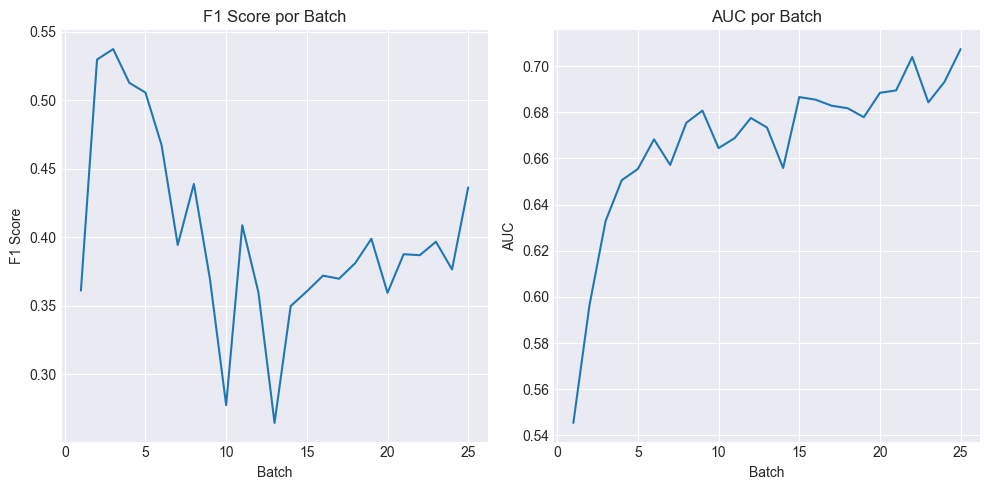

In [212]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.lineplot(x=range(1, len(f1_scores) + 1), y=f1_scores, ax=ax[0], markers='X')
ax[0].set_xlabel('Batch')
ax[0].set_ylabel('F1 Score')
ax[0].set_title('F1 Score por Batch')
ax[0].grid(True)
sns.lineplot(x=range(1, len(eval_scores) + 1), y=eval_scores, ax=ax[1], markers='X')
ax[1].set_xlabel('Batch')
ax[1].set_ylabel('AUC')
ax[1].set_title('AUC por Batch')
ax[1].grid(True)
plt.tight_layout()
plt.show()

In [213]:
# Transformación de test
X_test = test_transformed_df.drop(columns=['label'])
y_true = test_batch['label']

# Probabilidades y clases
y_pred_probs = model.predict(X_test)
y_pred_labels = (y_pred_probs > 0.5).astype(int)

# Métricas
print("📊 Métricas de Evaluación:")
print("Accuracy:", accuracy_score(y_true, y_pred_labels))
print("AUC:", roc_auc_score(y_true, y_pred_probs))
print("Log Loss:", log_loss(y_true, y_pred_probs))
print("Precision:", precision_score(y_true, y_pred_labels))
print("Recall (Sensibilidad):", recall_score(y_true, y_pred_labels))
print("F1 Score:", f1_score(y_true, y_pred_labels))

📊 Métricas de Evaluación:
Accuracy: 0.5839190698285489
AUC: 0.6322240464120467
Log Loss: 14.997076828921239
Precision: 0.272606911161128
Recall (Sensibilidad): 0.710244912038634
F1 Score: 0.3939915805587447


## XGBOOST - incremental y early_stoping 

Mejora data drifting impidiendo overfitting

In [219]:
#import warnings
#warnings.filterwarnings("ignore", message=".*Parameters: { \"use_label_encoder\" } are not used.*")
from typing import List, Tuple
def incremental_xgboost_training(batches: List[Tuple[pd.DataFrame, pd.DataFrame]], label_col: str = 'label'):
    model = None
    eval_scores = []
    f1_scores = []

    for i, (train_df, eval_df) in tqdm.notebook.tqdm(enumerate(batches, start=1)):
        print(f"### Entrenando batch {i}/{len(batches)}")

        # Separar features y etiquetas
        X_train, y_train = train_df.drop(columns=[label_col]), train_df[label_col]
        X_eval, y_eval = eval_df.drop(columns=[label_col]), eval_df[label_col]

        # Ajustar balance de clases
        pos_count = y_train.sum()
        neg_count = len(y_train) - pos_count
        if pos_count > 0 and neg_count > 0:
            scale_pos = neg_count / pos_count
            print(f"### Ajuste de clases: scale_pos_weight = {scale_pos:.2f}")
        else:
            scale_pos = 1.0
            print(f" ### WARNING : Batch {i} con clase única. Se usará scale_pos_weight = 1.0")

        if model is None:
            # Primer batch: modelo desde cero
            model = XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                eval_metric='logloss',
                objective='binary:logistic',
                tree_method='auto',
                scale_pos_weight=scale_pos,
                early_stopping_rounds=15,  # Añadido early stopping
            )
            model.fit(X_train, y_train, eval_set=[(X_eval, y_eval)], verbose=0)
        
        else:
            # Guardamos el modelo anterior para obtener su booster
            previous_model = model
        
            model = XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                eval_metric='logloss',
                objective='binary:logistic',
                tree_method='auto',
                scale_pos_weight=scale_pos,
                early_stopping_rounds=15,
            )
            # Usamos el booster del modelo anterior
            model.fit(X_train, y_train, xgb_model=previous_model.get_booster(), eval_set=[(X_eval, y_eval)], verbose=0)

        # Predicciones y evaluación
        y_pred_probs = model.predict_proba(X_eval)[:, 1]
        y_pred_labels = (y_pred_probs >= 0.5).astype(int)

        # Métricas de evaluación
        if len(np.unique(y_eval)) < 2:
            print(f"### ERROR : Batch {i} contiene una sola clase. AUC y F1 no disponibles.")
            auc, f1 = np.nan, np.nan
        else:
            auc = roc_auc_score(y_eval, y_pred_probs)
            f1 = f1_score(y_eval, y_pred_labels)
            print(f"✅ Batch {i} - AUC: {auc:.4f}, F1-score: {f1:.4f}")

        eval_scores.append(auc)
        f1_scores.append(f1)

    return model, eval_scores, f1_scores

In [220]:
model, eval_scores, f1_scores = incremental_xgboost_training(batches, label_col='label')

0it [00:00, ?it/s]

### Entrenando batch 1/25
### Ajuste de clases: scale_pos_weight = 0.23
✅ Batch 1 - AUC: 0.5473, F1-score: 0.1616
### Entrenando batch 2/25
### Ajuste de clases: scale_pos_weight = 0.89
✅ Batch 2 - AUC: 0.6303, F1-score: 0.4756
### Entrenando batch 3/25
### Ajuste de clases: scale_pos_weight = 1.26
✅ Batch 3 - AUC: 0.6360, F1-score: 0.4824
### Entrenando batch 4/25
### Ajuste de clases: scale_pos_weight = 1.70
✅ Batch 4 - AUC: 0.6708, F1-score: 0.5133
### Entrenando batch 5/25
### Ajuste de clases: scale_pos_weight = 2.13
✅ Batch 5 - AUC: 0.6808, F1-score: 0.5107
### Entrenando batch 6/25
### Ajuste de clases: scale_pos_weight = 2.06
✅ Batch 6 - AUC: 0.6923, F1-score: 0.4753
### Entrenando batch 7/25
### Ajuste de clases: scale_pos_weight = 2.88
✅ Batch 7 - AUC: 0.6888, F1-score: 0.4162
### Entrenando batch 8/25
### Ajuste de clases: scale_pos_weight = 4.06
✅ Batch 8 - AUC: 0.7083, F1-score: 0.4543
### Entrenando batch 9/25
### Ajuste de clases: scale_pos_weight = 3.47
✅ Batch 9 - AUC:

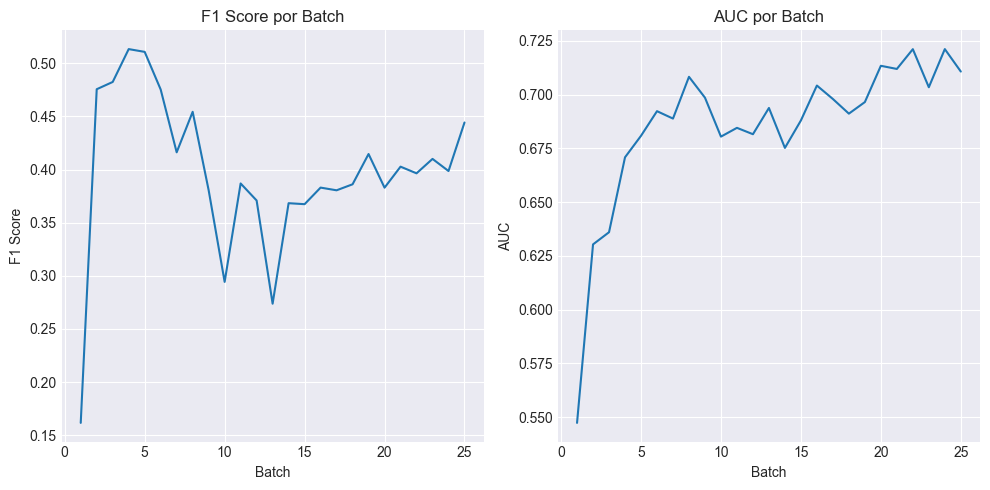

In [221]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.lineplot(x=range(1, len(f1_scores) + 1), y=f1_scores, ax=ax[0], markers='X')
ax[0].set_xlabel('Batch')
ax[0].set_ylabel('F1 Score')
ax[0].set_title('F1 Score por Batch')
ax[0].grid(True)
sns.lineplot(x=range(1, len(eval_scores) + 1), y=eval_scores, ax=ax[1], markers='X')
ax[1].set_xlabel('Batch')
ax[1].set_ylabel('AUC')
ax[1].set_title('AUC por Batch')
ax[1].grid(True)
plt.tight_layout()
plt.show()

In [222]:
# Transformación de test
X_test = test_transformed_df.drop(columns=['label'])
y_true = test_batch['label']

# Probabilidades y clases
y_pred_probs = model.predict(X_test)
y_pred_labels = (y_pred_probs > 0.5).astype(int)

# Métricas
print("📊 Métricas de Evaluación:")
print("Accuracy:", accuracy_score(y_true, y_pred_labels))
print("AUC:", roc_auc_score(y_true, y_pred_probs))
print("Log Loss:", log_loss(y_true, y_pred_probs))
print("Precision:", precision_score(y_true, y_pred_labels))
print("Recall (Sensibilidad):", recall_score(y_true, y_pred_labels))
print("F1 Score:", f1_score(y_true, y_pred_labels))

📊 Métricas de Evaluación:
Accuracy: 0.6789397622019313
AUC: 0.6437553761445457
Log Loss: 11.572183928221117
Precision: 0.3155893536121673
Recall (Sensibilidad): 0.5869265263884098
F1 Score: 0.41046981484832035


## XGBOOST - early stopping - decaimiento

* Podría tener mejoras a largo plazo

In [223]:
from typing import List, Tuple
def incremental_xgboost_training(batches: List[Tuple[pd.DataFrame, pd.DataFrame]], label_col: str = 'label'):
    model = None
    eval_scores = []
    f1_scores = []
    initial_lr = 0.01   # muy conservador al inicio
    final_lr = 0.1      # más agresivo al final
    total_batches = len(batches)


    for i, (train_df, eval_df) in tqdm.notebook.tqdm(enumerate(batches, start=1)):
            # Cálculo del learning_rate progresivo (lineal o exponencial)
        current_lr = initial_lr + (final_lr - initial_lr) * ((i - 1) / (total_batches - 1))
        print(f'### Warming up, current learning rate : {current_lr:.4f}')
        print(f"### Entrenando batch {i}/{len(batches)}")
        # Separar features y etiquetas
        X_train, y_train = train_df.drop(columns=[label_col]), train_df[label_col]
        X_eval, y_eval = eval_df.drop(columns=[label_col]), eval_df[label_col]

        # Ajustar balance de clases
        pos_count = y_train.sum()
        neg_count = len(y_train) - pos_count
        if pos_count > 0 and neg_count > 0:
            scale_pos = neg_count / pos_count
            print(f"### Ajuste de clases: scale_pos_weight = {scale_pos:.2f}")
        else:
            scale_pos = 1.0
            print(f" ### WARNING : Batch {i} con clase única. Se usará scale_pos_weight = 1.0")

        if model is None:
            # Primer batch: modelo desde cero
            model = XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=initial_lr,
                eval_metric='logloss',
                objective='binary:logistic',
                tree_method='auto',
                scale_pos_weight=scale_pos,
                early_stopping_rounds=15,  # Añadido early stopping
            )
            model.fit(X_train, y_train, eval_set=[(X_eval, y_eval)], verbose=0)
        
        else:
            # Guardamos el modelo anterior para obtener su booster
            previous_model = model
        
            model = XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=current_lr,
                eval_metric='logloss',
                objective='binary:logistic',
                tree_method='auto',
                scale_pos_weight=scale_pos,
                early_stopping_rounds=15,
            )
            # Usamos el booster del modelo anterior
            model.fit(X_train, y_train, xgb_model=previous_model.get_booster(), eval_set=[(X_eval, y_eval)], verbose=0)

        # Predicciones y evaluación
        y_pred_probs = model.predict_proba(X_eval)[:, 1]
        y_pred_labels = (y_pred_probs >= 0.5).astype(int)

        # Métricas de evaluación
        if len(np.unique(y_eval)) < 2:
            print(f"### ERROR : Batch {i} contiene una sola clase. AUC y F1 no disponibles.")
            auc, f1 = np.nan, np.nan
        else:
            auc = roc_auc_score(y_eval, y_pred_probs)
            f1 = f1_score(y_eval, y_pred_labels)
            print(f"✅ Batch {i} - AUC: {auc:.4f}, F1-score: {f1:.4f}")

        eval_scores.append(auc)
        f1_scores.append(f1)

    return model, eval_scores, f1_scores

In [224]:
model, eval_scores, f1_scores = incremental_xgboost_training(batches, label_col='label')

0it [00:00, ?it/s]

### Warming up, current learning rate : 0.0100
### Entrenando batch 1/25
### Ajuste de clases: scale_pos_weight = 0.23
✅ Batch 1 - AUC: 0.5473, F1-score: 0.1616
### Warming up, current learning rate : 0.0138
### Entrenando batch 2/25
### Ajuste de clases: scale_pos_weight = 0.89
✅ Batch 2 - AUC: 0.6351, F1-score: 0.5092
### Warming up, current learning rate : 0.0175
### Entrenando batch 3/25
### Ajuste de clases: scale_pos_weight = 1.26
✅ Batch 3 - AUC: 0.6595, F1-score: 0.4999
### Warming up, current learning rate : 0.0213
### Entrenando batch 4/25
### Ajuste de clases: scale_pos_weight = 1.70
✅ Batch 4 - AUC: 0.6719, F1-score: 0.5025
### Warming up, current learning rate : 0.0250
### Entrenando batch 5/25
### Ajuste de clases: scale_pos_weight = 2.13
✅ Batch 5 - AUC: 0.6746, F1-score: 0.4966
### Warming up, current learning rate : 0.0288
### Entrenando batch 6/25
### Ajuste de clases: scale_pos_weight = 2.06
✅ Batch 6 - AUC: 0.6915, F1-score: 0.4685
### Warming up, current learning r

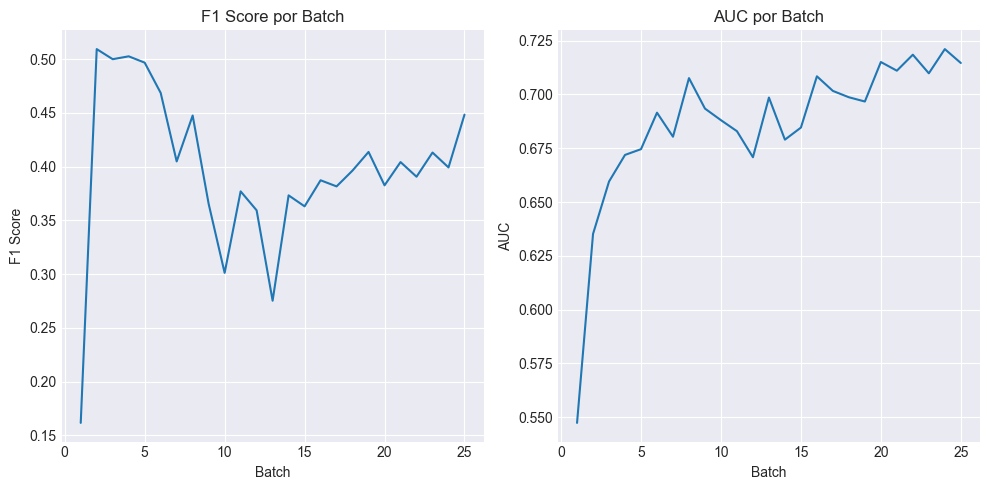

In [225]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.lineplot(x=range(1, len(f1_scores) + 1), y=f1_scores, ax=ax[0], markers='X')
ax[0].set_xlabel('Batch')
ax[0].set_ylabel('F1 Score')
ax[0].set_title('F1 Score por Batch')
ax[0].grid(True)
sns.lineplot(x=range(1, len(eval_scores) + 1), y=eval_scores, ax=ax[1], markers='X')
ax[1].set_xlabel('Batch')
ax[1].set_ylabel('AUC')
ax[1].set_title('AUC por Batch')
ax[1].grid(True)
plt.tight_layout()
plt.show()

## XGBOOST - early stopping - reset

In [ ]:
from typing import List, Tuple
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score
import matplotlib.pyplot as plt
import tqdm

def incremental_xgboost_training(
    batches: List[Tuple[pd.DataFrame, pd.DataFrame]],
    label_col: str = 'label',
    f1_threshold: float = 0.3,
    reset_window_size: int = 2,
    initial_lr: float = 0.01,
    final_lr: float = 0.1
):
    model = None
    eval_scores = []
    f1_scores = []
    resets = []

    total_batches = len(batches)
    reset_flag = False

    for i, (train_df, eval_df) in tqdm.notebook.tqdm(enumerate(batches, start=1)):
        print(f"\n Entrenando batch {i}/{total_batches}")

        ##  Warm-up invertido del learning_rate
        #current_lr = initial_lr + (final_lr - initial_lr) * ((i - 1) / (total_batches - 1))
        #print(f" learning_rate = {current_lr:.5f}")

        # Si hay reset, reentrenamos desde cero con una ventana de datos recientes
        if reset_flag:
            print(f"🔁 Reset activado. Usando ventana de entrenamiento de los últimos {reset_window_size} batches.")
            recent_batches = batches[max(0, i - reset_window_size):i]
            train_df = pd.concat([b[0] for b in recent_batches])
            reset_flag = False
            model = None  # Forzamos reinicialización

        X_train, y_train = train_df.drop(columns=[label_col]), train_df[label_col]
        X_eval, y_eval = eval_df.drop(columns=[label_col]), eval_df[label_col]

        # ⚖️ Ajuste de clases
        pos_count = y_train.sum()
        neg_count = len(y_train) - pos_count
        scale_pos = neg_count / pos_count if pos_count > 0 else 1.0
        print(f"⚖️ scale_pos_weight = {scale_pos:.2f}")

        # Entrenamiento (nuevo o incremental)
        if model is None:
            model = XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                eval_metric='logloss',
                objective='binary:logistic',
                tree_method='auto',
                scale_pos_weight=scale_pos,
                early_stopping_rounds=15,
            )
            model.fit(X_train, y_train, eval_set=[(X_eval, y_eval)], verbose=0)
        else:
            previous_model = model
            model = XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                eval_metric='logloss',
                objective='binary:logistic',
                tree_method='auto',
                scale_pos_weight=scale_pos,
                early_stopping_rounds=15,
            )
            model.fit(
                X_train, y_train,
                xgb_model=previous_model.get_booster(),
                eval_set=[(X_eval, y_eval)],
                verbose=0
            )

        # Evaluación
        y_pred_probs = model.predict_proba(X_eval)[:, 1]
        y_pred_labels = (y_pred_probs >= 0.5).astype(int)

        if len(np.unique(y_eval)) < 2:
            print(f"⚠️ Batch {i} con clase única. AUC y F1 no disponibles.")
            auc, f1 = np.nan, np.nan
        else:
            auc = roc_auc_score(y_eval, y_pred_probs)
            f1 = f1_score(y_eval, y_pred_labels)
            print(f"✅ AUC: {auc:.4f} | F1-score: {f1:.4f}")

        eval_scores.append(auc)
        f1_scores.append(f1)

        # Chequeo de reset
        if not np.isnan(f1) and f1 < f1_threshold:
            print(f"🔻 F1-score {f1:.4f} por debajo del umbral {f1_threshold:.2f}. Se programará un reset.")
            reset_flag = True
            resets.append(i)
        else:
            resets.append(None)

    return model, eval_scores, f1_scores, resets


In [252]:
model, eval_scores, f1_scores, resets = incremental_xgboost_training(batches, label_col='label', f1_threshold=0.3, reset_window_size=3)

0it [00:00, ?it/s]


📦 Entrenando batch 1/25
📉 learning_rate = 0.01000
⚖️ scale_pos_weight = 0.23
✅ AUC: 0.5473 | F1-score: 0.1616
🔻 F1-score 0.1616 por debajo del umbral 0.30. Se programará un reset.

📦 Entrenando batch 2/25
📉 learning_rate = 0.01375
🔁 Reset activado. Usando ventana de entrenamiento de los últimos 3 batches.
⚖️ scale_pos_weight = 0.57
✅ AUC: 0.6044 | F1-score: 0.2745
🔻 F1-score 0.2745 por debajo del umbral 0.30. Se programará un reset.

📦 Entrenando batch 3/25
📉 learning_rate = 0.01750
🔁 Reset activado. Usando ventana de entrenamiento de los últimos 3 batches.
⚖️ scale_pos_weight = 0.81
✅ AUC: 0.6702 | F1-score: 0.4265

📦 Entrenando batch 4/25
📉 learning_rate = 0.02125
⚖️ scale_pos_weight = 1.70
✅ AUC: 0.6931 | F1-score: 0.4495

📦 Entrenando batch 5/25
📉 learning_rate = 0.02500
⚖️ scale_pos_weight = 2.13
✅ AUC: 0.6612 | F1-score: 0.5052

📦 Entrenando batch 6/25
📉 learning_rate = 0.02875
⚖️ scale_pos_weight = 2.06
✅ AUC: 0.6785 | F1-score: 0.4655

📦 Entrenando batch 7/25
📉 learning_rate =

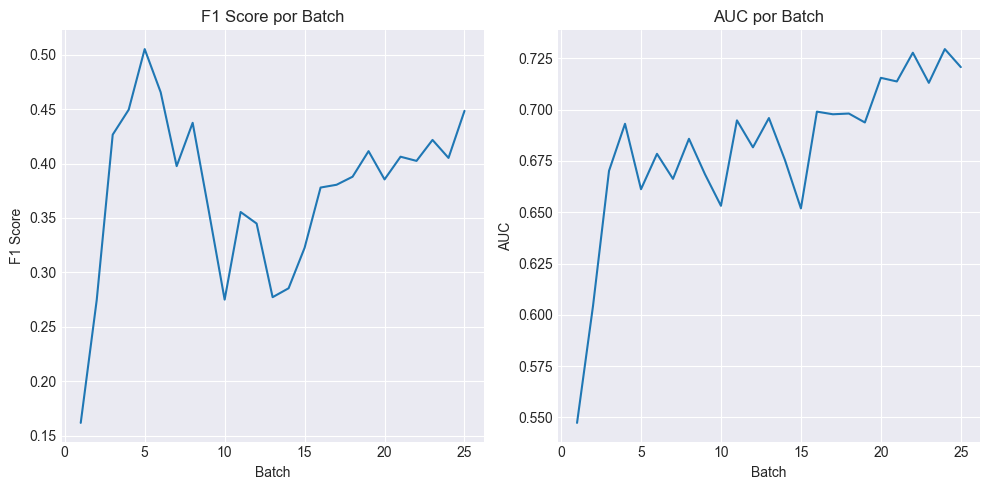

In [253]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
sns.lineplot(x=range(1, len(f1_scores) + 1), y=f1_scores, ax=ax[0], markers='X')
ax[0].set_xlabel('Batch')
ax[0].set_ylabel('F1 Score')
ax[0].set_title('F1 Score por Batch')
ax[0].grid(True)
sns.lineplot(x=range(1, len(eval_scores) + 1), y=eval_scores, ax=ax[1], markers='X')
ax[1].set_xlabel('Batch')
ax[1].set_ylabel('AUC')
ax[1].set_title('AUC por Batch')
ax[1].grid(True)
plt.tight_layout()
plt.show()

# IncrementalXGBOOST

In [ ]:
!pip install coloredlogs

In [ ]:
from typing import List, Tuple
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.base import BaseEstimator, ClassifierMixin
import matplotlib.pyplot as plt
import tqdm

### Requiere intalación
import coloredlogs, logging



# Batches (opcional reutilización)
class Batch:

    """
    Divide datos en ventanas con stride para train/val.
    """

    def __init__(self, data: pd.DataFrame, time_window_in_weeks: int, stride: int, col: str='week_num'):
        self.data = data.copy()
        self.time_window = time_window_in_weeks
        self.stride = stride
        self.col = col
        self._prepare()


    def _prepare(self):
        weeks = sorted(self.data[self.col].unique())
        n = len(weeks)
        self.weeks_batches = [weeks[i:i+self.time_window] for i in range(0, n-self.time_window+1, self.stride)]
        rem = weeks[n-self.time_window+self.stride:]
        if rem:
            if len(rem)<=self.time_window//2:
                self.weeks_batches[-1].extend(rem)
            else:
                self.weeks_batches.append(rem)


    def get_train_eval_batch(self, i:int):
        batch = self.weeks_batches[i]
        split = self.time_window-self.stride
        train = self.data[self.data[self.col].isin(batch[:split])]
        val   = self.data[self.data[self.col].isin(batch[split:])]
        return train, val


    def get_test_batch(self, week:int):
        return self.data[self.data[self.col]==week]
    

    def __len__(self): return len(self.weeks_batches)
    def __getitem__(self,index:int): return self.get_train_eval_batch(index)
    def __iter__(self):
        for i in range(len(self)): yield self.get_train_eval_batch(i)



class IncrementalXGBoost(BaseEstimator, ClassifierMixin):

    Recursive = 0
    logger = logging.getLogger(__name__) 
    coloredlogs.install(level='DEBUG', logger=logger)

    def __init__(self, batch_col='batch', label_col='label', f1_threshold=0.6,
                reset_window_size=6, initial_lr=0.01, final_lr=0.1, max_depth=6,
                n_estimators=100, log = True):

        self.batch_col = batch_col
        self.label_col = label_col
        self.history_ = []
        self.f1_threshold = f1_threshold
        self.reset_window_size = reset_window_size
        self.max_depth = max_depth
        self.n_estimators = n_estimators
        self.model = None
        self.log = log
        self.eval_scores = []
        self.f1_scores = []
        
    
    def fit(self, X : Batch, y):
        
        if not IncrementalXGBoost.Recursive:
            self.history_ = X
        total_batches = len(X)
        reset_flag = False
        model = self.model
        eval_scores = []
        f1_scores = []
        for i, (train_df, eval_df) in enumerate(X, start=1):

            


            # Data drift
            if reset_flag and IncrementalXGBoost.Recursive < 1:
                model = None
                if self.log: IncrementalXGBoost.logger.info(f"Reset activado. Usando ventana de entrenamiento de los últimos {self.reset_window_size} batches.")
                IncrementalXGBoost.Recursive += 1
                recent_batches = self.history_[max(0, i - self.reset_window_size):i]
                if self.log: IncrementalXGBoost.logger.warning(f"Incremental Reset es {IncrementalXGBoost.Recursive}")
                self.fit(recent_batches, None)
                if self.log: IncrementalXGBoost.logger.warning(f"Reset Terminado, se entrenará el modelo con los siguientes batches")
                reset_flag = False
                IncrementalXGBoost.Recursive = 0
            
            elif IncrementalXGBoost.Recursive >= 3: 
                IncrementalXGBoost.Recursive = 0
                return

            if self.log: IncrementalXGBoost.logger.info(f"Entrenando batch {i}/{total_batches}")
            X_train, y_train = train_df.drop(columns=[self.label_col]), train_df[self.label_col]
            X_eval, y_eval = eval_df.drop(columns=[self.label_col]), eval_df[self.label_col]
            
            # weighted class batches
            scale_pos = IncrementalXGBoost.scalePosWeight(y_train)
            #if self.log: IncrementalXGBoost.logger.info(f"scale_pos_weight = {scale_pos:.2f}")

            
            # Entrenamiento (nuevo o incremental)
            if model is None:
                model = XGBClassifier(
                    n_estimators=self.n_estimators,
                    max_depth=self.max_depth,
                    learning_rate=0.1,
                    eval_metric='auc',
                    objective='binary:logistic',
                    tree_method='auto',
                    scale_pos_weight=scale_pos,
                    early_stopping_rounds=12,
                )
                model.fit(X_train, y_train, eval_set=[(X_eval, y_eval)], verbose=0)

            else:
                # Entrenamos sobre el anterior.
                previous_model = model
                model = XGBClassifier(
                    n_estimators=self.n_estimators,
                    max_depth=self.max_depth,
                    learning_rate=0.1,
                    eval_metric='auc',
                    objective='binary:logistic',
                    tree_method='auto',
                    scale_pos_weight=scale_pos,
                    early_stopping_rounds=12,
                )
                model.fit(
                    X_train, y_train,
                    xgb_model=previous_model.get_booster(),
                    eval_set=[(X_eval, y_eval)],
                    verbose=0
                )
            
            # Evaluación
            y_pred_probs = model.predict_proba(X_eval)[:, 1]
            y_pred_labels = (y_pred_probs >= 0.5).astype(int)
    
            if len(np.unique(y_eval)) < 2:
                if self.log : IncrementalXGBoost.logger.warning("Batch {i} con clase única. AUC y F1 no disponibles.")
                auc, f1 = np.nan, np.nan
            else:
                auc = roc_auc_score(y_eval, y_pred_probs)
                f1 = f1_score(y_eval, y_pred_labels)
                if self.log : IncrementalXGBoost.logger.info(f"AUC: {auc:.4f} | F1-score: {f1:.4f}")
    
            eval_scores.append(auc)
            f1_scores.append(f1)
    
            # Chequeo de reset
            if i > 1 and IncrementalXGBoost.Recursive == 0:
                if IncrementalXGBoost.shouldReset(f1_scores[i-1], f1_scores[i-2]):
                    if self.log : IncrementalXGBoost.logger.warning(f"F1-score {f1:.4f} por debajo del umbral. Se programará un reset.")
                    reset_flag = True
        self.f1_scores = f1_scores
        self.eval_scores = eval_scores

    @staticmethod
    def shouldReset(f1_score : float, last_f1_score : float): 
        if (last_f1_score - f1_score) > .05 :
            return True
        else:
            return False
    

    def flushHistory(self):
        self.history_ = []

    @staticmethod
    def scalePosWeight(y_train) -> float:
        pos_count = y_train.sum()
        neg_count = len(y_train) - pos_count
        scale_pos = neg_count / pos_count if pos_count > 0 else 1.0
        return scale_pos


    def partial_fit(batches : Batch):
        ...

In [101]:
model_ = IncrementalXGBoost(reset_window_size=3)
model_.fit(batches, None)

2025-06-24 04:44:24 David __main__[18776] INFO Entrenando batch 1/17
2025-06-24 04:44:24 David __main__[18776] INFO AUC: 0.7168 | F1-score: 0.5182
2025-06-24 04:44:24 David __main__[18776] INFO Entrenando batch 2/17
2025-06-24 04:44:24 David __main__[18776] INFO AUC: 0.6463 | F1-score: 0.4760
2025-06-24 04:44:24 David __main__[18776] INFO Entrenando batch 3/17
2025-06-24 04:44:25 David __main__[18776] INFO AUC: 0.6622 | F1-score: 0.4849
2025-06-24 04:44:25 David __main__[18776] INFO Entrenando batch 4/17
2025-06-24 04:44:25 David __main__[18776] INFO AUC: 0.6755 | F1-score: 0.5084
2025-06-24 04:44:25 David __main__[18776] INFO Entrenando batch 5/17
2025-06-24 04:44:25 David __main__[18776] INFO AUC: 0.6875 | F1-score: 0.4284
2025-06-24 04:44:25 David __main__[18776] WARNING F1-score 0.4284 por debajo del umbral. Se programará un reset.
2025-06-24 04:44:25 David __main__[18776] INFO Reset activado. Usando ventana de entrenamiento de los últimos 3 batches.
2025-06-24 04:44:25 David __mai

In [102]:
data

[0.5182226660009985,
 0.47596821692504304,
 0.4848573948838577,
 0.5083512370919676,
 0.42840310507346824,
 0.48918042137535206,
 0.3550192139149194,
 0.42971667319493406,
 0.35747120755276557,
 0.38213702104826713,
 0.4143719220364847,
 0.4255698459187572,
 0.43875324675324673,
 0.4330660835762877,
 0.42810142379034544,
 0.4494850416871015,
 0.4712727594522245]

<Axes: >

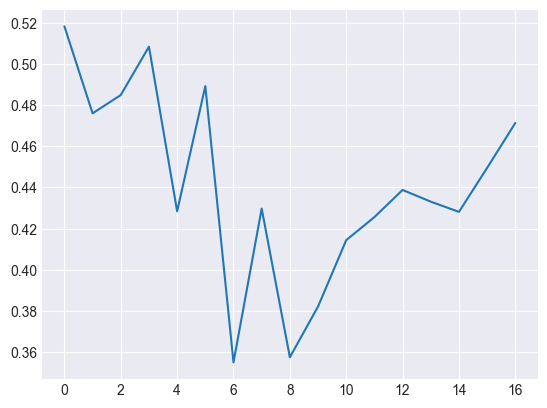

In [103]:
data = model_.f1_scores

sns.lineplot(y = data, x = list(range(len(data))))

In [255]:
# Transformación de test
X_test = test_transformed_df.drop(columns=['label'])
y_true = test_batch['label']

# Probabilidades y clases
y_pred_probs = model.predict(X_test)
y_pred_labels = (y_pred_probs > 0.5).astype(int)

# Métricas
print("📊 Métricas de Evaluación:")
print("Accuracy:", accuracy_score(y_true, y_pred_labels))
print("AUC:", roc_auc_score(y_true, y_pred_probs))
print("Log Loss:", log_loss(y_true, y_pred_probs))
print("Precision:", precision_score(y_true, y_pred_labels))
print("Recall (Sensibilidad):", recall_score(y_true, y_pred_labels))
print("F1 Score:", f1_score(y_true, y_pred_labels))

📊 Métricas de Evaluación:
Accuracy: 0.6753596531564081
AUC: 0.6505135809962115
Log Loss: 11.7012241377532
Precision: 0.3170010748835543
Recall (Sensibilidad): 0.610382890651949
F1 Score: 0.4172856974413395


In [86]:
from sklearn.utils.class_weight import compute_sample_weight # Para manejar los pesos por clase si es necesario


def incremental_xgboost_training(
    batches: list[tuple[pd.DataFrame, pd.DataFrame]],
    label_col: str = 'label',
    params: dict = None,
    decay: float = 0.85
):
    """
    Entrena un modelo de XGBoost de forma incremental por batches, ponderando más los datos recientes
    y manejando el desbalance de clases.

    batches: lista de tuplas (train_df, eval_df) donde cada df ya tiene las features transformadas
             y la columna 'label'.
    label_col: nombre de la columna objetivo.
    params: hiperparámetros de XGBoost.
    num_boost_round: rondas de boosting POR BATCH. Ajustar para evitar sobreajuste.
    decay: factor de decaimiento exponencial de pesos hacia atrás.

    Retorna:
        - modelo final entrenado
        - lista de métricas AUC por batch
    """
    if params is None:
        params = {
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'learning_rate': 0.1,
            'max_depth': 6,
            'verbosity': 0,
            'lambda': 1, 
            'alpha': 1,
            'umbalance':True,  # Para manejar el desbalance de clases
        }
    else:
        # Asegurarse de que el diccionario de params sea mutable si se pasa externamente
        params = params.copy()

    model = None
    eval_scores = []
    total_batches = len(batches)

    for i, (train_df, eval_df) in enumerate(batches):
        print(f"\n🧩 Entrenando batch {i+1}/{total_batches}")

        X_train = train_df.drop(columns=[label_col])
        y_train = train_df[label_col]
        X_eval = eval_df.drop(columns=[label_col])
        y_eval = eval_df[label_col]

        positive_count = y_train.sum()
        negative_count = len(y_train) - positive_count
        
        if positive_count > 0 and negative_count > 0:
            params['scale_pos_weight'] = negative_count / positive_count
            print(f"⚖️ 'scale_pos_weight' ajustado a: {params['scale_pos_weight']:.2f} (negativos: {negative_count}, positivos: {positive_count})")
        else:
            print(f"Advertencia: Batch {i+1} tiene solo una clase o ninguna positiva. 'scale_pos_weight' no se establecerá o será 1.")
            params['scale_pos_weight'] = 1.0 
        batch_weight_factor = decay ** 1/((total_batches - i)*2)
        sample_weights = np.full(len(y_train), batch_weight_factor)

        dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
        deval = xgb.DMatrix(X_eval, label=y_eval)

        # Entrenamiento incremental
        model = xgb.train(   # Asegurarse de que exista
            params=params,
            dtrain=dtrain,
            num_boost_round=int(200*0.5*(total_batches - 1 - i)),
            xgb_model=model,
            evals=[(deval, 'eval')],
            verbose_eval=False,
            
        )

        # Evaluación del modelo en el batch de validación actual
        y_pred_probs = model.predict(deval)
        y_pred_labels = (y_pred_probs >= 0.5).astype(int)

        unique_eval_labels = np.unique(y_eval)
        
        if len(unique_eval_labels) < 2:
            auc = np.nan # No se puede calcular AUC si solo hay una clase
            f1 = np.nan 
            print(f"❌ Advertencia: El batch de validación {i+1} tiene solo una clase ({unique_eval_labels[0]}). AUC y F1-score no calculables.")
        else:
            auc = roc_auc_score(y_eval, y_pred_probs)
            f1 = f1_score(y_eval, y_pred_labels)
            print(f"🔍 AUC en validación del batch {i+1}: {auc:.4f}")
            print(f"🔍 F1-score en validación del batch {i+1}: {f1:.4f}")

        eval_scores.append(auc)

    return model, eval_scores

In [178]:
from sklearn.utils.class_weight import compute_sample_weight # Para manejar los pesos por clase si es necesario
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, f1_score
from imblearn.under_sampling import RandomUnderSampler # Import for undersampling

def incremental_xgboost_training(
    batches: list[tuple[pd.DataFrame, pd.DataFrame]],
    label_col: str = 'label',
    params: dict = None,
    decay: float = 0.85
):
    """
    Entrena un modelo de XGBoost de forma incremental por batches, ponderando más los datos recientes
    y manejando el desbalance de clases con undersampling.

    batches: lista de tuplas (train_df, eval_df) donde cada df ya tiene las features transformadas
             y la columna 'label'.
    label_col: nombre de la columna objetivo.
    params: hiperparámetros de XGBoost.
    num_boost_round: rondas de boosting POR BATCH. Ajustar para evitar sobreajuste.
    decay: factor de decaimiento exponencial de pesos hacia atrás.

    Retorna:
        - modelo final entrenado
        - lista de métricas AUC por batch
    """
    if params is None:
        params = {
            'objective': 'binary:logistic',
            'eval_metric': 'auc', # 'auc' es generalmente preferido para desbalance
            'learning_rate': 0.1,
            'max_depth': 6,
            'verbosity': 0,
            'lambda': 1,
            'alpha': 1,
            # 'umbalance':True, -- This is a typo, removed. scale_pos_weight is handled below.
        }
    else:
        params = params.copy()

    model = None
    eval_scores = []
    total_batches = len(batches)

    rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)

    for i, (train_df, eval_df) in enumerate(batches):
        print(f"\n🧩 Entrenando batch {i+1}/{total_batches}")

        X_train = train_df.drop(columns=[label_col])
        y_train = train_df[label_col]
        X_eval = eval_df.drop(columns=[label_col])
        y_eval = eval_df[label_col]

        # --- Handle Class Imbalance with Random Undersampling ---
        positive_count = y_train.sum()
        negative_count = len(y_train) - positive_count

        if positive_count > 0 and negative_count > 0:
            # Undersample the majority class (0) to match the minority class (1)
            # This makes the training data 50/50 balanced for this batch
            X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)
            print(f"⚖️ Undersampling aplicado. Clases en batch de entrenamiento: {pd.Series(y_train_resampled).value_counts().to_dict()}")

            # IMPORTANT: If you apply undersampling, you usually DON'T need scale_pos_weight in XGBoost.
            # Undersampling already balances the data. Keeping both can over-correct.
            if 'scale_pos_weight' in params:
                del params['scale_pos_weight'] # Remove scale_pos_weight if present
        else:
            # If only one class is present, undersampling cannot be applied.
            # Use original data, but the model might still struggle if it never sees the other class.
            X_train_resampled, y_train_resampled = X_train, y_train
            print(f"Advertencia: Batch {i+1} tiene solo una clase o ninguna positiva. Undersampling no se aplicó.")
            # If only one class, remove scale_pos_weight as well for consistency
            if 'scale_pos_weight' in params:
                del params['scale_pos_weight']


        batch_weight_factor = decay ** (total_batches - 1 - i)*2


        sample_weights = np.full(len(y_train_resampled), batch_weight_factor)
        # --- END Temporal Decay Weighting ---

        # Create DMatrix with resampled data and sample weights
        dtrain = xgb.DMatrix(X_train_resampled, label=y_train_resampled, weight=sample_weights)
        deval = xgb.DMatrix(X_eval, label=y_eval)

        # Training Incremental
        # num_boost_round is now dynamically adjusted based on batch
        current_num_boost_round = int(150 * 0.5**(total_batches - 1 - i))
        # Ensure it's at least 1, or a sensible minimum
        if current_num_boost_round < 1:
            current_num_boost_round = 1
        print(f"📈 Rondas de boosting para este batch: {current_num_boost_round}")

        model = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=current_num_boost_round, # Use the dynamic num_boost_round
            xgb_model=model,
            evals=[(deval, 'eval')],
            verbose_eval=False,
        )

        # Evaluation on current validation batch
        y_pred_probs = model.predict(deval)
        y_pred_labels = (y_pred_probs >= 0.5).astype(int)

        unique_eval_labels = np.unique(y_eval)

        if len(unique_eval_labels) < 2:
            auc = np.nan
            f1 = np.nan
            print(f"❌ Advertencia: El batch de validación {i+1} tiene solo una clase ({unique_eval_labels[0]}). AUC y F1-score no calculables.")
        else:
            auc = roc_auc_score(y_eval, y_pred_probs)
            f1 = f1_score(y_eval, y_pred_labels)
            print(f"🔍 AUC en validación del batch {i+1}: {auc:.4f}")
            print(f"🔍 F1-score en validación del batch {i+1}: {f1:.4f}")

        eval_scores.append(auc)

    return model, eval_scores

In [182]:
model, eval_scores = incremental_xgboost_training(batches, label_col='label')


🧩 Entrenando batch 1/8
⚖️ 'scale_pos_weight' ajustado a: 0.93 (negativos: 22901, positivos: 24752)
🔍 AUC en validación del batch 1: 0.6893
🔍 F1-score en validación del batch 1: 0.4047

🧩 Entrenando batch 2/8
⚖️ 'scale_pos_weight' ajustado a: 2.25 (negativos: 55668, positivos: 24730)
🔍 AUC en validación del batch 2: 0.6858
🔍 F1-score en validación del batch 2: 0.4208

🧩 Entrenando batch 3/8
⚖️ 'scale_pos_weight' ajustado a: 4.47 (negativos: 84526, positivos: 18919)
🔍 AUC en validación del batch 3: 0.7134
🔍 F1-score en validación del batch 3: 0.3666

🧩 Entrenando batch 4/8
⚖️ 'scale_pos_weight' ajustado a: 5.69 (negativos: 102309, positivos: 17979)
🔍 AUC en validación del batch 4: 0.6950
🔍 F1-score en validación del batch 4: 0.3342

🧩 Entrenando batch 5/8
⚖️ 'scale_pos_weight' ajustado a: 5.03 (negativos: 112966, positivos: 22453)
🔍 AUC en validación del batch 5: 0.7389
🔍 F1-score en validación del batch 5: 0.4256

🧩 Entrenando batch 6/8
⚖️ 'scale_pos_weight' ajustado a: 4.79 (negativos

In [183]:
# Transformación de test
X_test_transformed = pipeline_fe.transform(test_batch)
X_test_df = pd.DataFrame(X_test_transformed, columns=pipeline_fe.get_feature_names_out())
X_test = X_test_df 
y_true = test_batch['label']

# XGBoost requiere DMatrix para predecir
dtest = xgb.DMatrix(X_test)

# Probabilidades y clases
y_pred_probs = model.predict(dtest)
y_pred_labels = (y_pred_probs > 0.5).astype(int)

# Métricas
print("📊 Métricas de Evaluación:")
print("Accuracy:", accuracy_score(y_true, y_pred_labels))
print("AUC:", roc_auc_score(y_true, y_pred_probs))
print("Log Loss:", log_loss(y_true, y_pred_probs))
print("Precision:", precision_score(y_true, y_pred_labels))
print("Recall (Sensibilidad):", recall_score(y_true, y_pred_labels))
print("F1 Score:", f1_score(y_true, y_pred_labels))

📊 Métricas de Evaluación:
Accuracy: 0.6784754538900177
AUC: 0.7228913419421932
Log Loss: 0.6169077252506647
Precision: 0.088094540482469
Recall (Sensibilidad): 0.6555232558139535
F1 Score: 0.15531640120533793
